# DASHBOARD - Credit Card Fraud Detection
# Comparing 5 different Machine Learning Algorithms
## May 7, 2026
## Hasaan Mohsin

In [9]:
# import the model performance metrics from the other notebooks

%store -r aprf_dt
%store -r aprf_rf
%store -r aprf_knn
%store -r aprf_lr
%store -r aprf_svm
%store -r aprf_xgb



In [10]:
dt = aprf_dt
rf = aprf_rf
lr = aprf_lr
knn = aprf_knn
svm = aprf_svm
xgb = aprf_xgb

In [11]:

model_performances = [dt, rf, lr, knn, svm, xgb]
model_performances


[[0.9991807403766253,
  0.7361111111111112,
  0.7681159420289855,
  0.75177304964539],
 [0.9995611109160493,
  0.974025974025974,
  0.7653061224489796,
  0.8571428571428571],
 [0.9390862944162437,
  0.967391304347826,
  0.9081632653061225,
  0.9368421052631579],
 [0.9994382219725431,
  0.852112676056338,
  0.8175675675675675,
  0.8344827586206897],
 [0.9358108108108109,
  0.9587628865979382,
  0.8611111111111112,
  0.9073170731707317],
 [0.9994850368081645,
  0.9256198347107438,
  0.7619047619047619,
  0.835820895522388]]

           Decision Tree  Random Forest       KNN       SVM  \
Accuracy        0.999181       0.999561  0.999438  0.935811   
Precision       0.736111       0.974026  0.852113  0.958763   
Recall          0.768116       0.765306  0.817568  0.861111   
F1 Score        0.751773       0.857143  0.834483  0.907317   

           Logistic Regression   XGBoost  
Accuracy              0.939086  0.999485  
Precision             0.967391  0.925620  
Recall                0.908163  0.761905  
F1 Score              0.936842  0.835821  


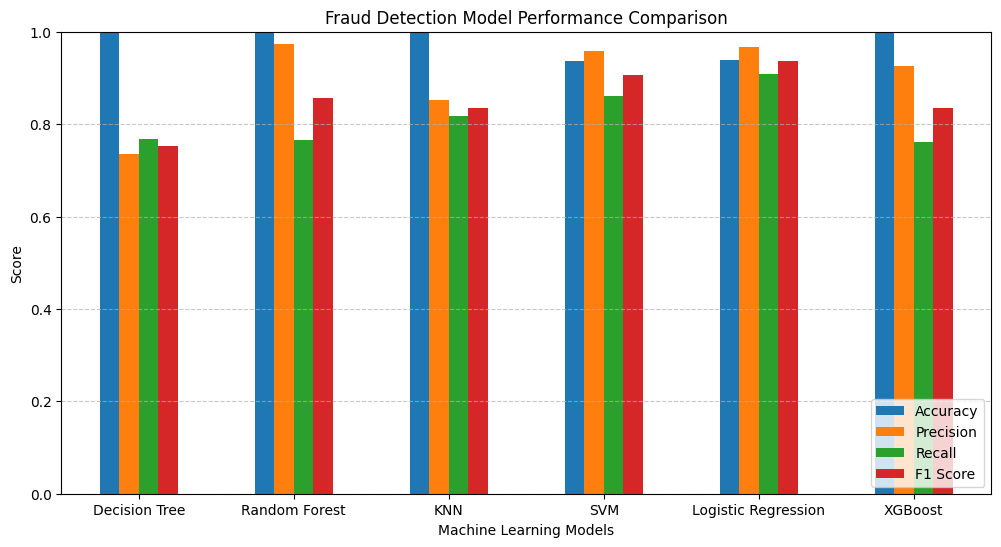

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create dataframe
results = pd.DataFrame({
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'SVM': svm,
    'Logistic Regression': lr,
    'XGBoost': xgb
}, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])

print(results)

# BAR CHART COMPARISON

results.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Fraud Detection Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Machine Learning Models')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [13]:
# FIND BEST MODEL
# Average score across all metrics
average_scores = results.mean()

print("\nAverage Scores:")
print(average_scores)

best_model = average_scores.idxmax()
best_score = average_scores.max()

print(f"\nBest Overall Model: {best_model}")
print(f"Average Performance Score: {best_score:.4f}")



Average Scores:
Decision Tree          0.813795
Random Forest          0.899009
KNN                    0.875900
SVM                    0.915750
Logistic Regression    0.937871
XGBoost                0.880708
dtype: float64

Best Overall Model: Logistic Regression
Average Performance Score: 0.9379


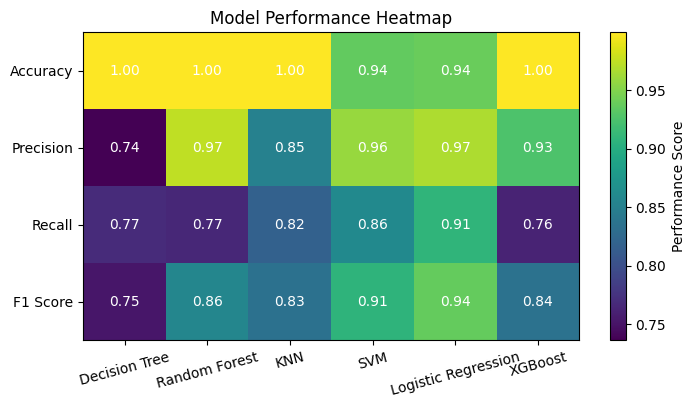

In [14]:
# HEATSYLE MAP VIEW

plt.figure(figsize=(8, 4))

plt.imshow(results, cmap='viridis', aspect='auto')

plt.colorbar(label='Performance Score')

plt.xticks(
    ticks=np.arange(len(results.columns)),
    labels=results.columns,
    rotation=15
)

plt.yticks(
    ticks=np.arange(len(results.index)),
    labels=results.index
)

plt.title('Model Performance Heatmap')

# Add values inside heatmap
for i in range(len(results.index)):
    for j in range(len(results.columns)):
        plt.text(
            j,
            i,
            f"{results.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            color='white'
        )

plt.show()